In [1]:
"""
Halo catalog to sentence tokenization for machine learning.
Converts Rockstar halo catalogs into tokenized sequences for transformer models.
"""

import numpy as np
import os
import pickle as pk
import gc
import MAS_library as MASL
import sys
# sys.path.append('/mnt/ceph/users/spandey/CHARM_v2/CHARM/prep_data')
from ngp_funcs import NGP_xyz_prop
from colossus.cosmology import cosmology
from colossus.halo import mass_so
os.environ['NUMBA_NUM_THREADS'] = str(os.cpu_count())
print("NUMBA_NUM_THREADS set to: ", os.environ['NUMBA_NUM_THREADS'])

# Optional numba for acceleration
try:
    from numba import njit, prange
    HAS_NUMBA = True
    print("Numba is available. Numba-accelerated functions will be used.")
except ImportError:
    HAS_NUMBA = False
    print("Warning: numba not available, using numpy fallback")


# =============================================================================
# Configuration
# =============================================================================

class Config:
    """All configuration parameters in one place."""
    # Grid parameters
    grid = 8
    # pos_nvocab = 40
    grid_sbox = 16
    grid_tot = grid * grid_sbox  # Total grid size after sub-boxing
    
    # Vocabulary
    # nvocab = 131
    # start_token = nvocab + 1
    # space_token = nvocab + 2
    # pad_token = nvocab + 3
    # end_token = nvocab + 4
    
    # Data dimensions
    dim_pos = 3
    dim_prop = 5
    dim_tot = dim_pos + dim_prop
    
    # Sentence parameters
    Npoints_max_per_subvol = 10
    # ind_token_to_sort = 3  # Sort by mass token
    # add_space_token = False
    # costoken_num = 5
    
    # Simulation parameters
    BoxSize = 1000.0
    redshift = 0.5
    snap_num = 3
    
    # Cosmology token ranges
    # Om_min, Om_max = 0.1, 0.5
    # Ob_min, Ob_max = 0.03, 0.07
    # h0_min, h0_max = 0.5, 0.9
    # ns_min, ns_max = 0.8, 1.2
    # sigma8_min, sigma8_max = 0.6, 1.0

    lgM_min, lgM_max = 12.7, 15.0
    v_min, v_max = -1250, 1250
    conc_min, conc_max = 1.0, 16.0
    
    # Paths
    sdir = '/mnt/ceph/users/spandey/discodj_runs/halos_story_nsel_32768'
    snap_dir_base = '/mnt/home/fvillaescusa/ceph/Quijote/Halos/Rockstar/latin_hypercube_HR'
    meta_dir = '/mnt/ceph/users/spandey/discodj_runs/rhog_LH_np_512_nsnap_3_nsel_32768'
    
    # @classmethod
    # def compute_bins(cls):
    #     """Compute digitization bins for each property."""
    #     bins = np.zeros((cls.dim_prop, cls.nvocab))
        
    #     # Mass bins
    #     bins[0] = np.linspace(12.7, 15.0, cls.nvocab)
        
    #     # Velocity bins (non-uniform: finer resolution near zero)
    #     # v_left = np.linspace(-1200, -100, cls.nvocab//3, endpoint=False)
    #     # v_mid = np.linspace(-100, 100, cls.nvocab - 2*(cls.nvocab//3), endpoint=False)
    #     # v_right = np.linspace(100, 1200, cls.nvocab//3, endpoint=True)
    #     # v_bins = np.concatenate((v_left, v_mid, v_right))
    #     v_bins = np.linspace(-1250, 1250, cls.nvocab)
    #     bins[1] = v_bins
    #     bins[2] = v_bins
    #     bins[3] = v_bins
        
    #     # Concentration bins
    #     bins[4] = np.linspace(1.0, 16.0, cls.nvocab)
        
    #     return bins
    
    @classmethod
    def get_max_sentence_length(cls):
        """Compute maximum sentence length."""
        return cls.Npoints_max_per_subvol * cls.dim_tot


# Pre-compute bins
# BINS_DIGITIZE = Config.compute_bins()
MSTAR_CUT = Config.lgM_min
PROP_MAX = np.array([Config.lgM_max, Config.v_max, Config.v_max, Config.v_max, Config.conc_max])
PROP_MIN = np.array([Config.lgM_min, Config.v_min, Config.v_min, Config.v_min, Config.conc_min])
MAX_SENTENCE_LENGTH = Config.get_max_sentence_length()


# =============================================================================
# Utility Functions
# =============================================================================

def mat_reshape(mat, grid1, grid2):
    """
    Reshape array from (grid1*grid2, grid1*grid2, grid1*grid2, ...) 
    to (grid1, grid1, grid1, grid2, grid2, grid2, ...).
    """
    if len(mat.shape) == 3:
        extra_dims = ()
    else:
        extra_dims = mat.shape[3:]
    
    n_extra = len(extra_dims)
    new_shape = (grid1, grid2, grid1, grid2, grid1, grid2) + extra_dims
    mat_rs = mat.reshape(new_shape)
    axes = (0, 2, 4, 1, 3, 5) + tuple(range(6, 6 + n_extra))
    return np.transpose(mat_rs, axes)


def tokenize_cosmo_param(value, vmin, vmax, nvocab):
    """Convert cosmological parameter to token."""
    token = np.round((value - vmin) / (vmax - vmin) * nvocab).astype(np.int16)
    return np.clip(token, 0, nvocab)


# =============================================================================
# Sentence Building Functions
# =============================================================================

def build_sentences_numpy(dfhalo_props_rs, Nhalos_rs, Om_token, sigma8_token, Ob_token, h0_token, ns_token, cfg):
    """
    Pure numpy implementation matching original logic exactly.
    Works without numba.
    """
    grid = cfg.grid
    grid_sbox = cfg.grid_sbox
    max_sent_len = MAX_SENTENCE_LENGTH
    
    sentences = np.full((grid, grid, grid, max_sent_len), cfg.pad_token, dtype=np.int16)
    total_halos_used = 0
    overflow_count = 0
    
    for jx in range(grid):
        for jy in range(grid):
            for jz in range(grid):
                props_subvol = dfhalo_props_rs[jx, jy, jz]
                Npoints_subvol = Nhalos_rs[jx, jy, jz]
                
                # Find cells with halos
                indsel = np.where(Npoints_subvol > 0)
                if len(indsel[0]) == 0:
                    sentences[jx, jy, jz, :7] = [cfg.start_token, Om_token, sigma8_token, Ob_token, h0_token, ns_token, cfg.end_token]
                    continue
                
                Npoints_sel = Npoints_subvol[indsel]
                props_sel = props_subvol[indsel]
                for ip in range(cfg.dim_prop):
                    props_sel[:, :, :, cfg.dim_pos + ip] = np.clip(
                        props_sel_orig[:, :, :, cfg.dim_pos + ip],
                        PROP_MIN[ip], PROP_MAX[ip]
                    )
                
                # Collect all halo tokens
                word_list = []
                for jc1 in range(len(Npoints_sel)):
                    n_pts = int(Npoints_sel[jc1])
                    for jc2 in range(n_pts):
                        pos_token = np.array([indsel[0][jc1], indsel[1][jc1], indsel[2][jc1]], dtype=np.int16)
                        prop_tokens = np.array([
                            np.digitize(props_sel[jc1, jc2, cfg.dim_pos + jp], BINS_DIGITIZE[jp])
                            for jp in range(cfg.dim_prop)
                        ], dtype=np.int16)
                        word_list.append(np.concatenate([pos_token, prop_tokens]))
                
                if len(word_list) == 0:
                    sentences[jx, jy, jz, :7] = [cfg.start_token, Om_token, sigma8_token, Ob_token, h0_token, ns_token, cfg.end_token]
                    continue
                
                word_array = np.array(word_list, dtype=np.int16)
                
                # Sort by mass token (descending)
                sort_idx = np.argsort(word_array[:, cfg.ind_token_to_sort])[::-1]
                word_array = word_array[sort_idx]
                
                # Truncate if needed
                if len(word_array) > cfg.Npoints_max_per_subvol:
                    overflow_count += 1
                    word_array = word_array[:cfg.Npoints_max_per_subvol]
                
                total_halos_used += len(word_array)
                
                # Build sentence
                if cfg.add_space_token:
                    space_col = np.full((len(word_array), 1), cfg.space_token, dtype=np.int16)
                    word_concat = np.hstack([word_array, space_col])
                    data_flat = word_concat.flatten()[:-1]
                else:
                    data_flat = word_array.flatten()
                
                sentence = np.concatenate([
                    [cfg.start_token, Om_token, sigma8_token, Ob_token, h0_token, ns_token, cfg.end_token],
                    data_flat,
                    [cfg.end_token]
                ]).astype(np.int16)
                
                sentences[jx, jy, jz, :len(sentence)] = sentence
    
    return sentences, overflow_count


# Numba-accelerated version (only defined if numba is available)
if HAS_NUMBA:
    @njit(parallel=True)
    def _build_sentences_numba(
        dfhalo_props_rs, Nhalos_rs,
        grid, grid_sbox, dim_tot, Npoints_max,
        max_sent_len, ind_sort, pad_token=-10000.
    ):
        """Numba-accelerated sentence building with parallel processing."""
        sentences = np.full((grid, grid, grid, max_sent_len), pad_token, dtype=np.float32)
        overflow_count = 0
        
        for jx in prange(grid):
            for jy in range(grid):
                for jz in range(grid):
                    props_here = dfhalo_props_rs[jx, jy, jz]
                    Npoints_here = Nhalos_rs[jx, jy, jz]
                    
                    # Count total points
                    total_points = 0
                    for i0 in range(grid_sbox):
                        for i1 in range(grid_sbox):
                            for i2 in range(grid_sbox):
                                total_points += int(Npoints_here[i0, i1, i2])
                    
                    # if total_points == 0:
                    #     sentences[jx, jy, jz, 0] = start_token
                    #     sentences[jx, jy, jz, 1] = Om_token
                    #     sentences[jx, jy, jz, 2] = sigma8_token
                    #     sentences[jx, jy, jz, 3] = Ob_token
                    #     sentences[jx, jy, jz, 4] = h0_token
                    #     sentences[jx, jy, jz, 5] = ns_token
                    #     sentences[jx, jy, jz, 6] = end_token
                    #     continue
                    if total_points == 0:
                        continue
                    # Collect all points
                    word_array = np.empty((total_points, dim_tot), dtype=np.int16)
                    idx = 0
                    for i0 in range(grid_sbox):
                        for i1 in range(grid_sbox):
                            for i2 in range(grid_sbox):
                                n_pts = int(Npoints_here[i0, i1, i2])
                                for jp in range(n_pts):
                                    word_array[idx, 0] = i0
                                    word_array[idx, 1] = i1
                                    word_array[idx, 2] = i2
                                    for ip in range(5):
                                        val = props_here[i0, i1, i2, jp, 3 + ip]
                                        tok = np.searchsorted(bins_digitize[ip], val)
                                        word_array[idx, 3 + ip] = np.int16(tok)
                                    idx += 1
                    
                    # Sort by ind_sort (descending)
                    sort_keys = word_array[:, ind_sort].copy()
                    sort_idx = np.argsort(sort_keys)[::-1]
                    word_array_sorted = word_array[sort_idx]
                    
                    # Truncate
                    n_use = min(total_points, Npoints_max)
                    if total_points > Npoints_max:
                        overflow_count += 1
                    
                    # Build sentence
                    sentences[jx, jy, jz, 0] = start_token
                    sentences[jx, jy, jz, 1] = Om_token
                    sentences[jx, jy, jz, 2] = sigma8_token
                    sentences[jx, jy, jz, 3] = Ob_token
                    sentences[jx, jy, jz, 4] = h0_token
                    sentences[jx, jy, jz, 5] = ns_token

                    
                    pos = 6
                    for i in range(n_use):
                        for j in range(dim_tot):
                            sentences[jx, jy, jz, pos] = word_array_sorted[i, j]
                            pos += 1
                    
                    sentences[jx, jy, jz, pos] = end_token
        
        return sentences, overflow_count
    
    def build_sentences_numba(dfhalo_props_rs, Nhalos_rs, Om_token, sigma8_token, Ob_token, h0_token, ns_token, cfg):
        """Wrapper for numba function with Config object."""
        return _build_sentences_numba(
            dfhalo_props_rs, Nhalos_rs, Om_token, sigma8_token, Ob_token, h0_token, ns_token,
            cfg.grid, cfg.grid_sbox, cfg.dim_tot, cfg.Npoints_max_per_subvol,
            cfg.start_token, cfg.end_token, cfg.pad_token,
            MAX_SENTENCE_LENGTH, BINS_DIGITIZE, cfg.ind_token_to_sort
        )


def build_sentences(dfhalo_props_rs, Nhalos_rs, Om_token, sigma8_token, Ob_token, h0_token, ns_token, cfg, use_numba=True):
    """
    Build sentences using the fastest available method.
    
    Args:
        use_numba: If True and numba available, use parallel numba version
    """
    if use_numba and HAS_NUMBA:
        return build_sentences_numba(dfhalo_props_rs, Nhalos_rs, Om_token, sigma8_token, Ob_token, h0_token, ns_token, cfg)
    return build_sentences_numpy(dfhalo_props_rs, Nhalos_rs, Om_token, sigma8_token, Ob_token, h0_token, ns_token, cfg)


# =============================================================================
# I/O and Processing Functions
# =============================================================================

def save_sentence_params():
    """Save sentence configuration parameters."""
    saved = {
        'max_sentence_length': MAX_SENTENCE_LENGTH,
        'grid': Config.grid,
        'grid_sbox': Config.grid_sbox,
        'Npoints_max_per_subvol': Config.Npoints_max_per_subvol,
        'BoxSize': Config.BoxSize,
        'nvocab': Config.nvocab,
        'pos_nvocab': Config.pos_nvocab,
        'start_token': Config.start_token,
        'pad_token': Config.pad_token,
        'end_token': Config.end_token,
        'space_token': Config.space_token,
        'bins_digitize': BINS_DIGITIZE,
        'dim_pos': Config.dim_pos,
        'dim_prop': Config.dim_prop
    }
    os.makedirs(Config.sdir, exist_ok=True)
    pk.dump(saved, open(f"{Config.sdir}/sentence_params.pkl", 'wb'))
    print("Sentence parameters saved.")


def load_halo_catalog(isim, cosmo_params):
    """Load and filter Rockstar halo catalog."""
    Om, Ob, h0, ns, sigma8 = cosmo_params
    
    # Set up colossus cosmology
    params = {
        'flat': True, 'H0': h0 * 100, 'Om0': Om,
        'Ob0': Ob, 'sigma8': sigma8, 'ns': ns
    }
    cosmology.setCosmology('myCosmo', persistence='', **params)
    
    # Load Rockstar catalog
    snapdir = f"{Config.snap_dir_base}/{isim}"
    catalog_file = f"{snapdir}/out_{Config.snap_num}_pid.list"
    
    with open(catalog_file, 'r') as f:
        header = f.readline().split()
    
    rockstar = np.loadtxt(catalog_file)
    
    # Extract properties
    pos = rockstar[:, header.index('X'):header.index('Z')+1]
    mass = rockstar[:, header.index('M200c')]
    lgMass = np.log10(mass).astype(np.float32)
    lgMass = np.clip(lgMass, 0, PROP_MAX[0])
    
    vel = rockstar[:, header.index('VX'):header.index('VZ')+1]
    
    # Concentration
    Rhalo = (1 + Config.redshift) * mass_so.M_to_R(mass, Config.redshift, '200c')
    Rs = rockstar[:, header.index('Rs')]
    conc = Rhalo / Rs
    
    pid = rockstar[:, -1]
    
    # Stack properties: [lgM, vx, vy, vz, conc]
    props = np.column_stack((lgMass, vel, conc))
    
    # Filter: central halos above mass cut
    mask = (pid == -1) & (lgMass > MSTAR_CUT)
    
    return pos[mask].astype(np.float32), props[mask].astype(np.float32)


def process_LH_sim(isim, use_numba=True, randsel=True):
    """Process a single Latin Hypercube simulation."""
    # Setup output directory
    sdir_isim = f"{Config.sdir}/{isim}"
    os.makedirs(sdir_isim, exist_ok=True)

    if randsel:
        savefname = f"{sdir_isim}/halo_sentence_LH_{isim}.npy"
    else:
        savefname = f"{sdir_isim}/halo_sentence_LH_{isim}_full.npy"


    # if file does not exist, proceed
    if os.path.exists(savefname):
        print(f"Sim {isim}: Output file already exists. Skipping processing.")
        return
    else:

        # Load metadata
        meta_file = f"{Config.meta_dir}/{isim}/meta_dmo_fields_subvols_grid_8_LH_{isim}.pkl"
        with open(meta_file, 'rb') as f:
            metaf = pk.load(f)
        if randsel:
            rand_sel = metaf['rand_sel']
        else:
            rand_sel = np.arange(Config.grid**3)

        cosmo = metaf['cosmo']
        
        Om = cosmo['Omega_c'] + cosmo['Omega_b']
        Ob = cosmo['Omega_b']
        h0 = cosmo['h']
        ns = cosmo['n_s']
        sigma8 = cosmo['sigma8']
        
        # Tokenize cosmological parameters
        Om_token = tokenize_cosmo_param(Om, Config.Om_min, Config.Om_max, Config.nvocab)
        sigma8_token = tokenize_cosmo_param(sigma8, Config.sigma8_min, Config.sigma8_max, Config.nvocab)
        Ob_token = tokenize_cosmo_param(Ob, Config.Ob_min, Config.Ob_max, Config.nvocab)
        h0_token = tokenize_cosmo_param(h0, Config.h0_min, Config.h0_max, Config.nvocab)
        ns_token = tokenize_cosmo_param(ns, Config.ns_min, Config.ns_max, Config.nvocab)
        
        # Load halo catalog
        pos, props = load_halo_catalog(isim, (Om, Ob, h0, ns, sigma8))
        
        # NGP assignment to grid
        grid_tot = Config.grid_tot
        Nhalos = np.zeros((grid_tot, grid_tot, grid_tot), dtype=np.float32)
        MASL.NGP(pos, Nhalos, Config.BoxSize)
        
        nMax = int(np.amax(Nhalos))
        dfhalo_props = np.zeros(
            (grid_tot, grid_tot, grid_tot, nMax, Config.dim_pos + Config.dim_prop),
            dtype=np.float32
        )
        NGP_xyz_prop(pos, props, dfhalo_props, Config.BoxSize)
        
        # Reshape to subvolume structure
        Nhalos_rs = mat_reshape(Nhalos, Config.grid, Config.grid_sbox)
        dfhalo_props_rs = mat_reshape(dfhalo_props, Config.grid, Config.grid_sbox)
        
        # Free memory
        del pos, props, Nhalos, dfhalo_props
        gc.collect()
        
        # Build sentences
        sentences, overflow = build_sentences(
            dfhalo_props_rs, Nhalos_rs, Om_token, sigma8_token, Ob_token, h0_token, ns_token, Config, use_numba=use_numba
        )
        
        if overflow > 0:
            print(f"Sim {isim}: {overflow} subvolumes exceeded max points ({Config.Npoints_max_per_subvol})")
        
        # Flatten and apply random selection
        story_full = sentences.reshape((Config.grid**3, MAX_SENTENCE_LENGTH))
        np.save(savefname, story_full[rand_sel].astype(np.int16))
        
        # Cleanup
        del dfhalo_props_rs, Nhalos_rs, sentences, story_full
        gc.collect()
        return


# =============================================================================
# Entry Point
# =============================================================================


# gc.collect()

# sim_id = int(sys.argv[1])

# process_LH_sim(sim_id)

# if __name__ == "__main__":
#     save_sentence_params()
    
    # Example: process single simulation
    # process_LH_sim(0)
    
    # For batch processing with MPI:
    # from mpi4py import MPI
    # comm = MPI.COMM_WORLD
    # for isim in range(1000):
    #     if isim % comm.size == comm.rank:
    #         process_LH_sim(isim)

NUMBA_NUM_THREADS set to:  64
Numba is available. Numba-accelerated functions will be used.


In [21]:
import numpy as np
LH_cosmo_val_file='/mnt/ceph/users/spandey/Quijote/latin_hypercube_params.txt'
cosmo_vals = np.loadtxt(LH_cosmo_val_file)
isim = 453
Om, Ob, h0, ns, sigma8 = cosmo_vals[isim]
pos, props = load_halo_catalog(isim, (Om, Ob, h0, ns, sigma8))




/tmp/ipykernel_1228247/1959838122.py:383: RuntimeWarning: divide by zero encountered in log10
  lgMass = np.log10(mass).astype(np.float32)


In [22]:
np.argsort(cosmo_vals[:, 0])


array([1945,  987,   95, ...,  453,  753, 1154])

In [23]:
Om, Ob, h0, ns, sigma8


(0.49950000000000006, 0.06607000000000002, 0.8081, 1.0983, 0.8073)

In [24]:
grid_tot = 128
Nhalos = np.zeros((grid_tot, grid_tot, grid_tot), dtype=np.float32)
MASL.NGP(pos, Nhalos, Config.BoxSize)



In [31]:
np.where(Nhalos == np.amax(Nhalos))
# Nhalos.shape


(array([7]), array([12]), array([86]))

In [25]:
int(np.amax(Nhalos))


13

In [26]:
nMax = int(np.amax(Nhalos))
dfhalo_props = np.zeros(
    (grid_tot, grid_tot, grid_tot, nMax, Config.dim_pos + Config.dim_prop),
    dtype=np.float32
)
NGP_xyz_prop(pos, props, dfhalo_props, Config.BoxSize)


In [32]:
dfhalo_props[7,12,86,0,:]


array([ 2.5446587e+00,  7.4051666e-01, -4.1394043e-01,  1.3160198e+01,
       -4.7698999e+02,  2.2925000e+02,  1.0069300e+03,  5.7679758e+00],
      dtype=float32)

In [33]:
import matplotlib.pyplot as plt
%matplotlib inline


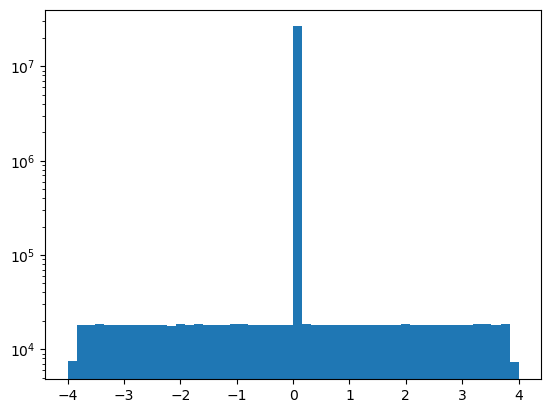

In [39]:
plt.figure()
_ = plt.hist(dfhalo_props[...,0].flatten(), bins=50, range=(-4, 4))
plt.yscale('log')


In [ ]:
def reconstruct_pos_from_dfhalo_props(dfhalo_props, BoxSize, pos_orig=None):
    """
    Reconstruct actual 3D halo positions from the NGP_xyz_prop grid output.

    NGP_xyz_prop stores, for each halo assigned to voxel (ix, iy, iz):
        dfhalo_props[ix, iy, iz, j, 0:3] = sub-voxel offset from voxel reference point
        dfhalo_props[ix, iy, iz, j, 3:]  = halo properties (logM, vx, vy, vz, conc, ...)

    The voxel reference point for axis k is:  round(pos_k * dims/BoxSize) * cell_size
    So the actual position is:  voxel_index * cell_size + stored_offset

    Parameters
    ----------
    dfhalo_props : np.ndarray, shape (dims, dims, dims, nMax, dim_tot)
    BoxSize      : float
    pos_orig     : np.ndarray, shape (N, 3), optional
        Original catalog positions. If provided, pos_rec is returned in the
        same order as pos_orig (matched via lexicographic sort).

    Returns
    -------
    pos_rec : np.ndarray, shape (N_halos, 3) — positions in [0, BoxSize],
              in voxel-scan order by default, or catalog order if pos_orig given.
    """
    dims = dfhalo_props.shape[0]
    cell_size = BoxSize / dims

    # Voxel reference coordinates — shape (dims, dims, dims, 3)
    ix, iy, iz = np.meshgrid(np.arange(dims), np.arange(dims), np.arange(dims), indexing='ij')
    voxel_ref = np.stack([ix, iy, iz], axis=-1).astype(np.float32) * cell_size

    # Broadcast to (dims, dims, dims, nMax, 3) and add sub-voxel offsets
    actual_pos = voxel_ref[:, :, :, np.newaxis, :] + dfhalo_props[..., :3]

    # Occupied slots have non-zero mass (logM > 12.7, always non-zero)
    occupied = dfhalo_props[..., 3] != 0

    pos_rec = actual_pos[occupied] % BoxSize  # (N_halos, 3), voxel-scan order

    if pos_orig is not None:
        # Reorder pos_rec to match pos_orig via lexicographic sort on all 3 axes.
        # Both arrays contain the same positions so sorted versions are identical.
        sort_rec  = np.lexsort(pos_rec.T[::-1])   # sort pos_rec
        sort_orig = np.lexsort(pos_orig.T[::-1])   # sort pos_orig
        # inv_sort_orig[i] = rank of pos_orig[i] in sorted order
        inv_sort_orig = np.empty_like(sort_orig)
        inv_sort_orig[sort_orig] = np.arange(len(sort_orig))
        # pos_rec[sort_rec] aligns with pos_orig[sort_orig], so undo pos_orig sort:
        pos_rec = pos_rec[sort_rec][inv_sort_orig]

    return pos_rec


# --- verify ---
pos_rec = reconstruct_pos_from_dfhalo_props(dfhalo_props, Config.BoxSize, pos_orig=pos)
print(f"Max abs difference from pos: {np.abs(pos - pos_rec).max():.6f}")
print(f"All close: {np.allclose(pos, pos_rec, atol=1e-4)}")


In [55]:
import Pk_library as PKL
grid = 128
MAS = 'CIC'
verbose = False
delta_q = np.zeros((grid,grid,grid), dtype=np.float32)

# construct 3D density field
MASL.MA(pos, delta_q, Config.BoxSize, MAS, verbose=verbose)
delta_q /= np.mean(delta_q, dtype=np.float32);  delta_q -= 1.0

delta_rec = np.zeros_like(delta_q)
MASL.MA(pos_rec, delta_rec, Config.BoxSize, MAS, verbose=verbose)
delta_rec /= np.mean(delta_rec, dtype=np.float32);  delta_rec -= 1.0

import Pk_library as PKL

Pk = PKL.XPk([delta_rec,delta_q], Config.BoxSize, 0, MAS=['CIC','CIC'], threads=1)



Computing power spectra of the fields...
Time FFTS = 0.02
Time loop = 0.04
Time taken = 0.07 seconds


(0.9, 1.1)

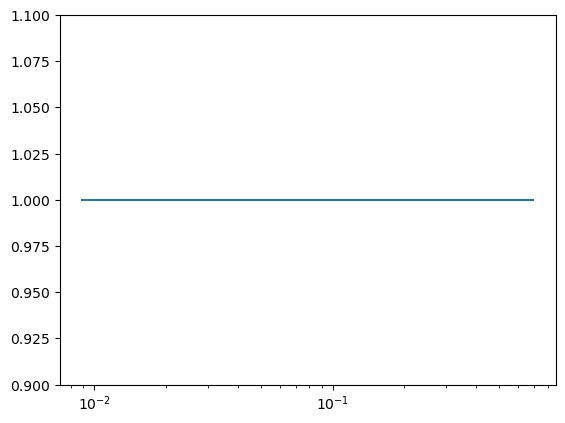

In [60]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(Pk.k3D, Pk.XPk[:,0,0]/np.sqrt(Pk.Pk[:,0,0] * Pk.Pk[:,0,1]), label='Disco-DJ')
plt.xscale('log')
plt.ylim(0.9, 1.1)



(0.9, 1.1)

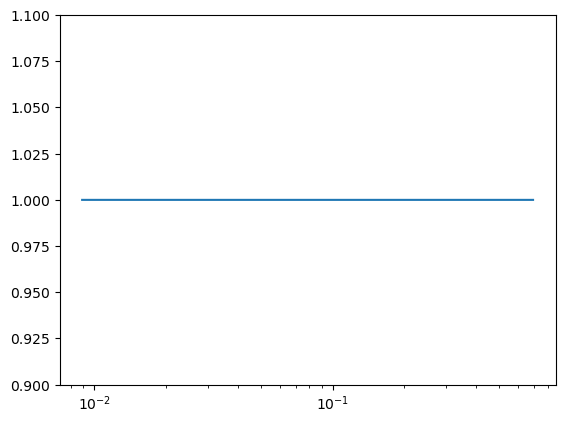

In [59]:
plt.figure()
plt.plot(Pk.k3D, Pk.Pk[:,0,0] / Pk.Pk[:,0,1], label='Disco-DJ')
plt.xscale('log')
plt.ylim(0.9, 1.1)


In [5]:
import readgadget
import readfof
import sys, os
import readgadget
import numpy as np
import matplotlib.pyplot as pl
from ngp_funcs import NGP_xyz_prop
import dill
from tqdm import tqdm
import sparse
import MAS_library as MASL
import colossus
from colossus.cosmology import cosmology
from colossus.halo import mass_so
from colossus.lss import peaks
from colossus.halo import concentration




In [10]:
mass_type = 'rockstar_200c'
snapnum = 3
isim = 453
isfid=False
z_dict = {4:0.0, 3:0.5, 2:1.0, 1:2.0, 0:3.0, -1: 127}

grid = 128
BoxSize = 1000.
Mmin_cut = 5e12
Mmin_cut_str = '5e12'
n_batch = 8
save_subvol = True
save_full = True
save_vel=True
LH_cosmo_val_file='/mnt/ceph/users/spandey/Quijote/latin_hypercube_params.txt'



In [18]:
redshift = z_dict[snapnum]


if isfid:
    root_out = '/mnt/home/spandey/ceph/Quijote/data_NGP_self'
else:
    root_out = '/mnt/home/spandey/ceph/Quijote/data_NGP_self_LH'
folder_out = '%s/%d'%(root_out,isim)
# create output folder if it does not exists
if not(os.path.exists(folder_out)):
    os.system('mkdir %s'%folder_out)

savefname_halos_subvol = '%s/SPARSEMATS_halos_HR_%s_lgMmincut_%s_subvol_res_%d_z=%s.pk'%(folder_out,mass_type,Mmin_cut_str,grid,redshift)
savefname_halos_full = '%s/SPARSEMATS_halos_HR_%s_lgMmincut_%s_full_res_%d_z=%s.pk'%(folder_out,mass_type,Mmin_cut_str,grid,redshift)       
try:
    saved_halos_full = dill.load(open(savefname_halos_full, 'rb'))
    c_halos_diff_combined = saved_halos_full['c_halos_diff_combined']
    nu_halos_combined = saved_halos_full['nu_halos_combined']
except:
    if isfid:
        cosmo_val_all = np.array([0.3175, 0.049, 0.6711, 0.9624, 0.834])
    else:
        cosmo_val_all = np.loadtxt(LH_cosmo_val_file)[isim]

    Om0 = cosmo_val_all[0]
    Ob0 = cosmo_val_all[1]
    h0 = cosmo_val_all[2]
    ns = cosmo_val_all[3]
    sigma8 = cosmo_val_all[4]
    params = {'flat': True, 'H0': h0*100, 'Om0': Om0, 'Ob0': Ob0, 'sigma8': sigma8, 'ns': ns}
    cosmo = cosmology.setCosmology('myCosmo', **params)

    if 'rockstar' in mass_type:
        if isfid:
            snap_dir_base = '/mnt/home/fvillaescusa/ceph/Quijote/Halos/Rockstar/fiducial_HR'        
        else:            
            snap_dir_base = '/mnt/home/fvillaescusa/ceph/Quijote/Halos/Rockstar/latin_hypercube_HR'
        verbose = False   #print information on progress
        snapdir = snap_dir_base + '/' + str(isim)  #folder hosting the catalogue
        rockstar = np.loadtxt(snapdir + '/out_' + str(snapnum) + '_pid.list')
        pid = rockstar[:, -1]
        indsel = np.where(pid == -1)[0]
        rockstar = rockstar[indsel]
        with open(snapdir + '/out_' + str(snapnum) + '_pid.list', 'r') as f:
            lines = f.readlines()
        header = lines[0].split()
        # get the properties of the halos
        pos_h_truth = rockstar[:,header.index('X'):header.index('Z')+1]
        if '200c' in mass_type:
            index_M = header.index('M200c')                    
            mass_truth = rockstar[:,index_M]  #Halo masses in Msun/h
            Rhalo = (1+redshift)*mass_so.M_to_R(mass_truth, redshift, '200c')        
        
        if 'vir' in mass_type:
            index_M = header.index('Mvir')
            mass_truth = rockstar[:,index_M]
            index_R = header.index('Rvir')
            Rhalo = rockstar[:,index_R]

        Rs = rockstar[:,header.index('Rs')]
        conc_sim = Rhalo/Rs
        
        lgMass_truth = np.log10(mass_truth).astype(np.float32)
        vel_h_truth = rockstar[:,header.index('VX'):header.index('VZ')+1]
        

    if 'fof' in mass_type:
        if isfid:
            snap_dir_base = '/mnt/home/fvillaescusa/ceph/Quijote/Halos/FoF/fiducial_HR' 
        else:
            snap_dir_base = '/mnt/home/fvillaescusa/ceph/Quijote/Halos/FoF/latin_hypercube_HR'
        snapdir = snap_dir_base + '/' + str(isim)  #folder hosting the catalogue
        FoF = readfof.FoF_catalog(snapdir, snapnum, long_ids=False, swap=False, SFR=False, read_IDs=False)
        # get the properties of the halos
        pos_h_truth = FoF.GroupPos / 1e3  #Halo positions in Mpc/h
        mass_truth = FoF.GroupMass * 1e10  #Halo masses in Msun/h
        lgMass_truth = np.log10(mass_truth).astype(np.float32)
        vel_h_truth = FoF.GroupVel*(1.0+redshift) #Halo peculiar velocities in km/s

        conc_sim = np.zeros_like(mass_truth)


    indsel = np.where(mass_truth > Mmin_cut)[0]
    pos_h_truth = pos_h_truth[indsel]
    mass_truth = mass_truth[indsel]
    lgMass_truth = lgMass_truth[indsel]
    vel_h_truth = vel_h_truth[indsel]
    # nu = peaks.peakHeight(mass_truth, redshift)
    conc_sim = conc_sim[indsel]
    conc_func = concentration.concentration(mass_truth, '200c', redshift, model = 'diemer19')
    delta_conc = conc_sim - conc_func 

    from scipy.interpolate import RegularGridInterpolator
    xall = (np.linspace(0, BoxSize, grid + 1))
    xarray = 0.5 * (xall[1:] + xall[:-1])
    yarray = np.copy(xarray)
    zarray = np.copy(xarray)

    if save_vel:
        import pickle as pk
        if isfid:
            vel_load_dir = '/mnt/ceph/users/spandey/Quijote/data_NGP_self/fastpm/'
        else:
            vel_load_dir = '/mnt/ceph/users/spandey/Quijote/data_NGP_self_fastpm_LH/'
        df = pk.load(open(vel_load_dir + f'{isim}/velocity_HR_full_m_res_128_z={redshift}_nbatch_8_nfilter_3_ncnn_0.pk', 'rb'))['velocity_cic_unpad_combined']
        vx_mesh_load = 1000.*df[0,...]
        vy_mesh_load = 1000.*df[1,...]
        vz_mesh_load = 1000.*df[2,...]

        vx_all_3D_interp_l = RegularGridInterpolator((xarray, yarray, zarray), vx_mesh_load, bounds_error=False, fill_value=None)
        vy_all_3D_interp_l = RegularGridInterpolator((xarray, yarray, zarray), vy_mesh_load, bounds_error=False, fill_value=None)
        vz_all_3D_interp_l = RegularGridInterpolator((xarray, yarray, zarray), vz_mesh_load, bounds_error=False, fill_value=None)

        vx_eval_interp_l = vx_all_3D_interp_l(pos_h_truth)
        vy_eval_interp_l = vy_all_3D_interp_l(pos_h_truth)
        vz_eval_interp_l = vz_all_3D_interp_l(pos_h_truth)

    vel_h_pred = np.array([vx_eval_interp_l, vy_eval_interp_l, vz_eval_interp_l]).T

    Nhalos = np.float32(np.zeros((grid, grid, grid)))
    MASL.NGP(np.float32(pos_h_truth), Nhalos, BoxSize)
    print('max number of halos:', np.amax(Nhalos))

    if grid == 64:
        nMax_h = 30  # maximum number of halos expected in a cell
    elif grid == 128:
        nMax_h = 10
    elif grid == 256:
        nMax_h = 8
    elif grid == 512:
        nMax_h = 3
    elif grid == 1024:
        nMax_h = 2
    else:
        print('nside not supported')
        sys.exit()


    props = np.concatenate([lgMass_truth[:,None], conc_sim[:,None], conc_func[:,None], delta_conc[:,None], vel_h_truth, vel_h_pred], axis=-1)
    dim_pos = pos_h_truth.shape[-1]
    dim_prop = props.shape[-1]
    dfhalo_props = np.zeros(
        (grid, grid, grid, nMax_h, dim_pos + dim_prop),
        dtype=np.float32
    )
    NGP_xyz_prop(np.float32(pos_h_truth), np.float32(props), dfhalo_props, BoxSize)


    argsort_M = np.flip(np.argsort(dfhalo_props[..., 3], axis=-1), axis=-1)
    dfhalo_props_sorted = np.take_along_axis(dfhalo_props, argsort_M[..., None], axis=-2)
    M_halos = dfhalo_props_sorted[..., 3]
    conc_sim_halos = dfhalo_props_sorted[..., 4]
    conc_func_halos = dfhalo_props_sorted[..., 5]
    conc_diff_halos = dfhalo_props_sorted[..., 6]

    dfhalo_ngp_pos_true = dfhalo_props_sorted[..., :3]

    dfhalo_ngp_wvall_true = dfhalo_props_sorted[..., 7:10]
    dfhalo_ngp_wvall_pred = dfhalo_props_sorted[..., 10:13]
    dfhalo_ngp_wvall_diff =  dfhalo_ngp_wvall_pred - dfhalo_ngp_wvall_true


    if save_subvol:
        # now split it into nbatches each side
        subvol_size = grid // n_batch
        nsubvol = n_batch**3
        save_subvol_Nhalo = np.zeros((nsubvol, subvol_size, subvol_size, subvol_size))
        save_subvol_Mhalo = np.zeros((nsubvol, subvol_size, subvol_size, subvol_size, nMax_h))
        # save_subvol_nuhalo = np.zeros((nsubvol, subvol_size, subvol_size, subvol_size, nMax_h))
        save_subvol_concsimhalos = np.zeros((nsubvol, subvol_size, subvol_size, subvol_size, nMax_h))
        save_subvol_concfunchalos = np.zeros((nsubvol, subvol_size, subvol_size, subvol_size, nMax_h))
        save_subvol_concdiffhalos = np.zeros((nsubvol, subvol_size, subvol_size, subvol_size, nMax_h))
        save_subvol_vtrue = np.zeros((nsubvol, subvol_size, subvol_size, subvol_size, nMax_h, 3))
        save_subvol_vpred = np.zeros((nsubvol, subvol_size, subvol_size, subvol_size, nMax_h, 3))
        save_subvol_vdiff = np.zeros((nsubvol, subvol_size, subvol_size, subvol_size, nMax_h, 3))
        save_subvol_pos = np.zeros((nsubvol, subvol_size, subvol_size, subvol_size, nMax_h, 3))

        jc = 0
        from tqdm import tqdm
        for jx in (range(n_batch)):
            for jy in range(n_batch):
                for jz in range(n_batch):
                    # get the sub-cube
                    save_subvol_Nhalo[jc] = Nhalos[jx * subvol_size:(jx + 1) * subvol_size,
                                                jy * subvol_size:(jy + 1) * subvol_size,
                                                jz * subvol_size:(jz + 1) * subvol_size]
                    save_subvol_Mhalo[jc] = dfhalo_props_sorted[..., 3][jx * subvol_size:(jx + 1) * subvol_size,
                                                    jy * subvol_size:(jy + 1) * subvol_size,
                                                    jz * subvol_size:(jz + 1) * subvol_size]
                    
                    save_subvol_concsimhalos[jc] = dfhalo_props_sorted[..., 4][jx * subvol_size:(jx + 1) * subvol_size,
                                                    jy * subvol_size:(jy + 1) * subvol_size,
                                                    jz * subvol_size:(jz + 1) * subvol_size]

                    save_subvol_concfunchalos[jc] = dfhalo_props_sorted[..., 5][jx * subvol_size:(jx + 1) * subvol_size,
                                                    jy * subvol_size:(jy + 1) * subvol_size,
                                                    jz * subvol_size:(jz + 1) * subvol_size]
                    save_subvol_concdiffhalos[jc] = dfhalo_props_sorted[..., 6][jx * subvol_size:(jx + 1) * subvol_size,
                                                    jy * subvol_size:(jy + 1) * subvol_size,
                                                    jz * subvol_size:(jz + 1) * subvol_size]

                    save_subvol_vtrue[jc] = dfhalo_ngp_wvall_true[jx * subvol_size:(jx + 1) * subvol_size,
                                                    jy * subvol_size:(jy + 1) * subvol_size,
                                                    jz * subvol_size:(jz + 1) * subvol_size]

                    save_subvol_vpred[jc] = dfhalo_ngp_wvall_pred[jx * subvol_size:(jx + 1) * subvol_size,
                                                    jy * subvol_size:(jy + 1) * subvol_size,
                                                    jz * subvol_size:(jz + 1) * subvol_size]

                    save_subvol_vdiff[jc] = dfhalo_ngp_wvall_diff[jx * subvol_size:(jx + 1) * subvol_size,
                                                    jy * subvol_size:(jy + 1) * subvol_size,
                                                    jz * subvol_size:(jz + 1) * subvol_size]
                    
                    save_subvol_pos[jc] = dfhalo_ngp_pos_true[jx * subvol_size:(jx + 1) * subvol_size,
                                                    jy * subvol_size:(jy + 1) * subvol_size,
                                                    jz * subvol_size:(jz + 1) * subvol_size]


                    jc += 1

    #     save_subvol_Nhalo = sparse.COO(save_subvol_Nhalo)
    #     save_subvol_Mhalo = sparse.COO(save_subvol_Mhalo)
    #     save_subvol_pos = sparse.COO(save_subvol_pos)
    #     # save_subvol_nuhalo = sparse.COO(save_subvol_nuhalo)
    #     save_subvol_concsimhalos = sparse.COO(save_subvol_concsimhalos)
    #     save_subvol_concfunchalos = sparse.COO(save_subvol_concfunchalos)
    #     save_subvol_concdiffhalos = sparse.COO(save_subvol_concdiffhalos)
    #     save_subvol_vtrue = sparse.COO(save_subvol_vtrue)
    #     save_subvol_vpred = sparse.COO(save_subvol_vpred)
    #     save_subvol_vdiff = sparse.COO(save_subvol_vdiff)
    #     saved_halos_subvol = {
    #         'N_halos': save_subvol_Nhalo,
    #         'M_halos': save_subvol_Mhalo,
    #         'pos_halos': save_subvol_pos,
    #         # 'nu_halos': save_subvol_nuhalo,
    #         'c_halos_sim': save_subvol_concsimhalos,
    #         'c_halos_func': save_subvol_concfunchalos,
    #         'c_halos_diff': save_subvol_concdiffhalos,
    #         'v_halos_true': save_subvol_vtrue,
    #         'v_halos_pred': save_subvol_vpred,
    #         'v_halos_diff': save_subvol_vdiff
    #         }    
    #     # dill.dump(saved_halos_subvol, open(savefname_halos_subvol, 'wb'))

    # if save_full:
    #     Nhalos = sparse.COO(Nhalos)
    #     M_halos = sparse.COO(M_halos)
    #     pos_halos = sparse.COO(dfhalo_ngp_pos_true)
    #     # nu_halos = sparse.COO(nu_halos)
    #     conc_sim_halos = sparse.COO(conc_sim_halos)
    #     conc_func_halos = sparse.COO(conc_func_halos)
    #     conc_diff_halos = sparse.COO(conc_diff_halos)
    #     dfhalo_ngp_wvall_true = sparse.COO(dfhalo_ngp_wvall_true)
    #     dfhalo_ngp_wvall_pred = sparse.COO(dfhalo_ngp_wvall_pred)
    #     dfhalo_ngp_wvall_diff = sparse.COO(dfhalo_ngp_wvall_diff)
    #     saved_halos_full = {
    #         'N_halos_combined': Nhalos,
    #         'M_halos_combined': M_halos,
    #         'pos_halos_combined': pos_halos,
    #         # 'nu_halos_combined': nu_halos,
    #         'c_halos_sim_combined': conc_sim_halos,
    #         'c_halos_func_combined': conc_func_halos,
    #         'c_halos_diff_combined': conc_diff_halos,
    #         'v_halos_true_combined': dfhalo_ngp_wvall_true,
    #         'v_halos_pred_combined': dfhalo_ngp_wvall_pred,
    #         'v_halos_diff_combined': dfhalo_ngp_wvall_diff
    #         }    
    #     # dill.dump(saved_halos_full, open(savefname_halos_full, 'wb'))


mkdir: cannot create directory ‘/mnt/home/spandey/ceph/Quijote/data_NGP_self_LH/453’: No such file or directory
/tmp/ipykernel_2837469/2931391682.py:63: RuntimeWarning: divide by zero encountered in log10
  lgMass_truth = np.log10(mass_truth).astype(np.float32)


max number of halos: 13.0


In [19]:
# M_halos.shape
np.where(Nhalos == np.amax(Nhalos))


(array([7]), array([12]), array([86]))

In [22]:
# M_halos[7,12,86,:]
len(np.where(M_halos != 0)[0])


887559

In [23]:
np.sum(Nhalos)

887568.0

In [1]:
import h5py as h5
import matplotlib.pyplot as plt
%matplotlib inline


In [38]:
ldir = '/mnt/ceph/users/spandey/CHARM_v2/data/trial_Mmin1e14/shards/'
fname = ldir + 'CHARM_train_shard_0.h5'
df = h5.File(fname, 'r')
# print(df['halos'].keys())
M1_norm = df['halos']['M1_norm'][:]
N_halos = df['halos']['N_halos'][:]
Mdiff_norm = df['halos']['Mdiff_norm'][:]
c_norm = df['halos']['c_norm'][:]
pos_norm = df['halos']['pos_norm'][:]
v_norm = df['halos']['v_norm'][:]
df.close()



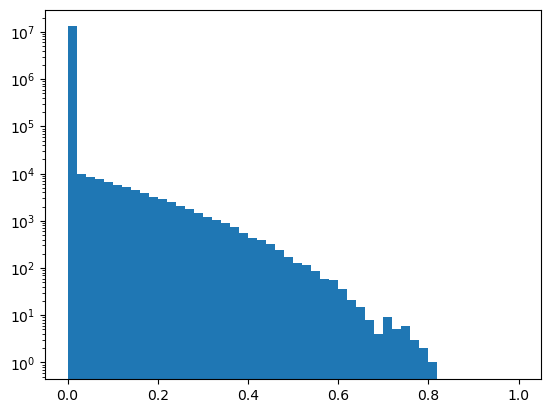

In [44]:
plt.figure()
_ = plt.hist(M1_norm.flatten(), bins=50, range=(0, 1))
# _ = plt.hist(N_halos.flatten(), bins=50, range=(0, 5))
# _ = plt.hist(Mdiff_norm.flatten(), bins=50, range=(0, 1))
# _ = plt.hist(c_norm.flatten(), bins=50)
# _ = plt.hist(pos_norm.flatten(), bins=50)
# _ = plt.hist(v_norm.flatten(), bins=50)
plt.yscale('log')


Shapes — M1:(3200, 4096)  N:(3200, 4096)  Mdiff:(3200, 4096, 3)  c:(3200, 4096, 4)  pos:(3200, 4096, 12)  v:(3200, 4096, 12)


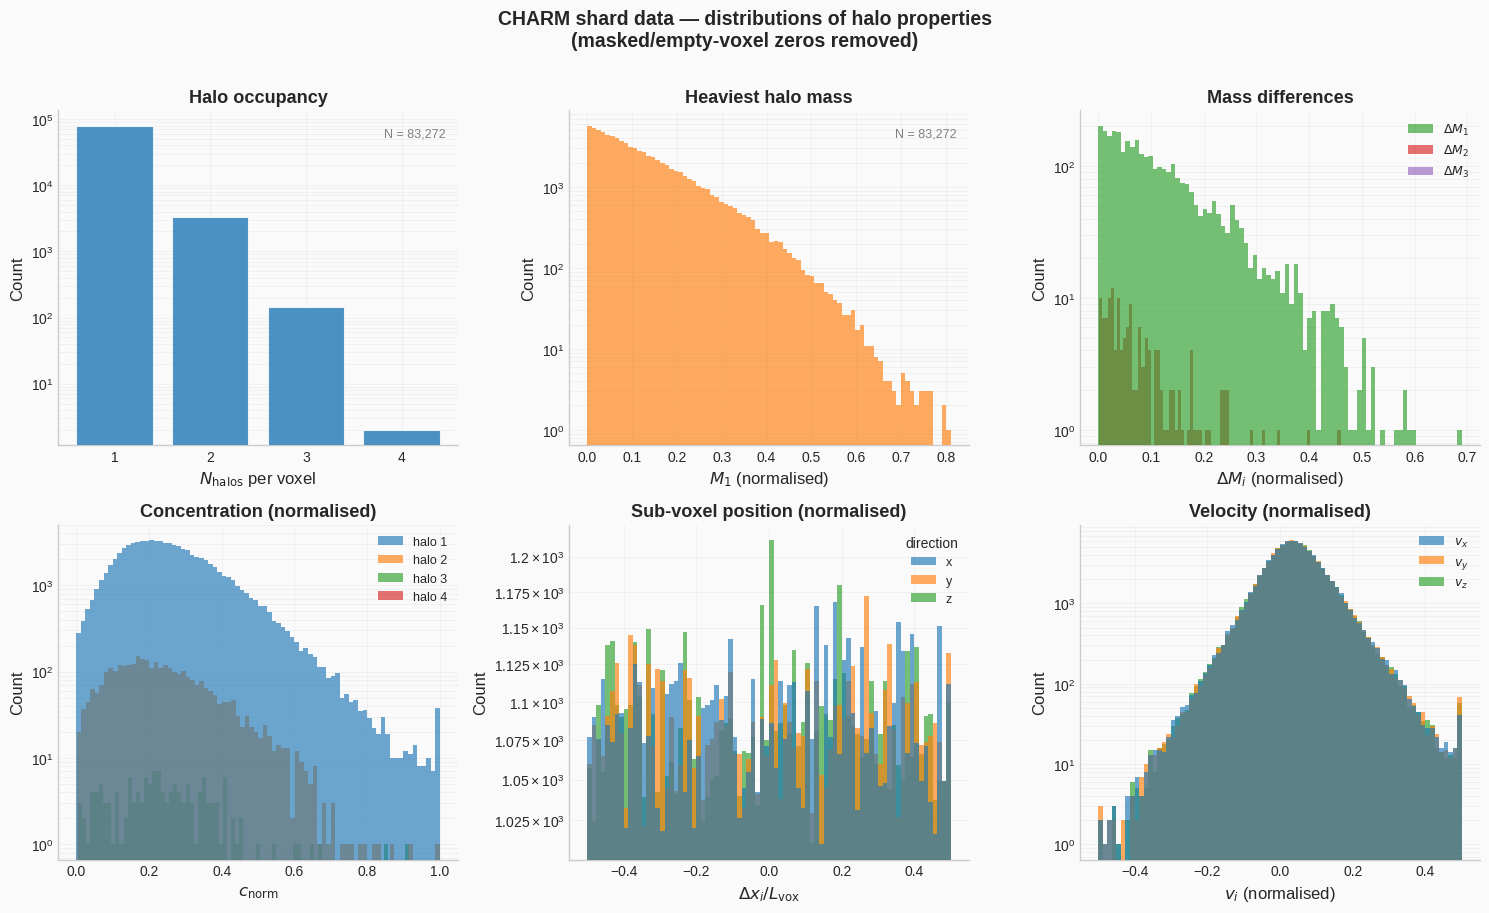

In [45]:
"""
Multi-panel histogram of all CHARM training shard quantities.
Masked (zero-padded) values are excluded from every panel.
"""
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Load shard ────────────────────────────────────────────────────────────────
ldir  = '/mnt/ceph/users/spandey/CHARM_v2/data/trial_Mmin1e14/shards/'
fname = ldir + 'CHARM_train_shard_0.h5'

with h5.File(fname, 'r') as df:
    M1_norm   = df['halos']['M1_norm'][:]      # (n_outer, N_vox, 1)
    N_halos   = df['halos']['N_halos'][:]      # (n_outer, N_vox)
    Mdiff_norm = df['halos']['Mdiff_norm'][:]  # (n_outer, N_vox, Nmax-1=3)
    c_norm    = df['halos']['c_norm'][:]       # (n_outer, N_vox, Nmax=4)
    pos_norm  = df['halos']['pos_norm'][:]     # (n_outer, N_vox, Nmax*3=12)
    v_norm    = df['halos']['v_norm'][:]       # (n_outer, N_vox, Nmax*3=12)

print(f"Shapes — M1:{M1_norm.shape}  N:{N_halos.shape}  Mdiff:{Mdiff_norm.shape}  "
      f"c:{c_norm.shape}  pos:{pos_norm.shape}  v:{v_norm.shape}")

# ── Style ─────────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE   = plt.cm.tab10.colors
BG        = '#fafafa'
BINS      = 80
ALPHA     = 0.65
LW        = 1.3

def nonzero(arr):
    """Flatten and keep only strictly non-zero entries."""
    flat = arr.ravel().astype(np.float32)
    return flat[flat != 0.0]

def nonzero_component(arr, comp):
    """Return non-zero values of component `comp` (last axis)."""
    return nonzero(arr[..., comp])

# ── Figure layout ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.patch.set_facecolor(BG)
axes = axes.ravel()

for ax in axes:
    ax.set_facecolor(BG)

# ─────────────────────────────────────────────────────────────────────────────
# Panel 0 — N_halos  (integer counts)
# ─────────────────────────────────────────────────────────────────────────────
ax = axes[0]
n_flat = N_halos.ravel().astype(np.int32)
n_masked = n_flat[n_flat > 0]          # 0 means empty voxel
vals, cnts = np.unique(n_masked, return_counts=True)
ax.bar(vals, cnts, color=PALETTE[0], alpha=0.8, edgecolor='white', linewidth=0.8,
       zorder=3)
ax.set_yscale('log')
ax.set_xlabel(r'$N_{\rm halos}$ per voxel', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Halo occupancy', fontsize=13, fontweight='bold')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.text(0.97, 0.95, f'N = {len(n_masked):,}', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='grey')

# ─────────────────────────────────────────────────────────────────────────────
# Panel 1 — M1_norm  (single component)
# ─────────────────────────────────────────────────────────────────────────────
ax = axes[1]
m1_flat = nonzero(M1_norm)
ax.hist(m1_flat, bins=BINS, color=PALETTE[1], alpha=ALPHA, edgecolor='none',
        log=True, zorder=3)
ax.set_xlabel(r'$M_1$ (normalised)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Heaviest halo mass', fontsize=13, fontweight='bold')
ax.text(0.97, 0.95, f'N = {len(m1_flat):,}', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='grey')

# ─────────────────────────────────────────────────────────────────────────────
# Panel 2 — Mdiff_norm  (3 components = Δ1, Δ2, Δ3)
# ─────────────────────────────────────────────────────────────────────────────
ax = axes[2]
Ncomp_mdiff = Mdiff_norm.shape[-1]
for i in range(Ncomp_mdiff):
    d = nonzero_component(Mdiff_norm, i)
    label = rf'$\Delta M_{i+1}$'
    ax.hist(d, bins=BINS, color=PALETTE[i+2], alpha=ALPHA, edgecolor='none',
            log=True, label=label, zorder=3 - i * 0.1)
ax.set_xlabel(r'$\Delta M_i$ (normalised)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Mass differences', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.7)

# ─────────────────────────────────────────────────────────────────────────────
# Panel 3 — c_norm  (4 components = halos 1–4)
# ─────────────────────────────────────────────────────────────────────────────
ax = axes[3]
Ncomp_c = c_norm.shape[-1]
for i in range(Ncomp_c):
    d = nonzero_component(c_norm, i)
    label = rf'halo {i+1}'
    ax.hist(d, bins=BINS, color=PALETTE[i], alpha=ALPHA, edgecolor='none',
            log=True, label=label, zorder=3 - i * 0.1)
ax.set_xlabel(r'$c_{\rm norm}$', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Concentration (normalised)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.7)

# ─────────────────────────────────────────────────────────────────────────────
# Panel 4 — pos_norm  (12 = 4 halos × 3 directions; overlay x/y/z)
# ─────────────────────────────────────────────────────────────────────────────
ax = axes[4]
dir_labels = ['x', 'y', 'z']
dir_colors = [PALETTE[0], PALETTE[1], PALETTE[2]]
Nmax = pos_norm.shape[-1] // 3
for d_idx, (dlabel, dcolor) in enumerate(zip(dir_labels, dir_colors)):
    # Gather this direction across all Nmax halos
    comp_indices = [d_idx + 3 * h for h in range(Nmax)]
    vals = np.concatenate([nonzero_component(pos_norm, ci) for ci in comp_indices])
    ax.hist(vals, bins=BINS, color=dcolor, alpha=ALPHA, edgecolor='none',
            log=True, label=dlabel, zorder=3 - d_idx * 0.1)
ax.set_xlabel(r'$\Delta x_i / L_{\rm vox}$', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Sub-voxel position (normalised)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.7, title='direction')

# ─────────────────────────────────────────────────────────────────────────────
# Panel 5 — v_norm  (12 = 4 halos × 3 directions; overlay vx/vy/vz)
# ─────────────────────────────────────────────────────────────────────────────
ax = axes[5]
for d_idx, (dlabel, dcolor) in enumerate(zip(dir_labels, dir_colors)):
    comp_indices = [d_idx + 3 * h for h in range(Nmax)]
    vals = np.concatenate([nonzero_component(v_norm, ci) for ci in comp_indices])
    ax.hist(vals, bins=BINS, color=dcolor, alpha=ALPHA, edgecolor='none',
            log=True, label=f'$v_{dlabel}$', zorder=3 - d_idx * 0.1)
ax.set_xlabel(r'$v_i$ (normalised)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Velocity (normalised)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.7)

# ── Shared polish ─────────────────────────────────────────────────────────────
for ax in axes:
    ax.tick_params(labelsize=10)
    ax.grid(True, which='both', alpha=0.3, linewidth=0.5)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('CHARM shard data — distributions of halo properties\n'
             '(masked/empty-voxel zeros removed)',
             fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()

# out_path = ldir + 'shard_histograms.png'
# fig.savefig(out_path, dpi=150, bbox_inches='tight', facecolor=BG)
# print(f"Saved → {out_path}")
plt.show()


In [3]:
import h5py as h5
import matplotlib.pyplot as plt
%matplotlib inline


In [4]:
# fname = '/mnt/ceph/users/spandey/CHARM_v2/data/halos_Mmin5e12/3/halos_rockstar_200c_z0.5.h5'
fname = '/mnt/ceph/users/spandey/CHARM_v2/data/halos_processed/0/halos_rockstar_200c_z0.5.h5'
df = h5.File(fname, 'r')
# print(df.keys())
Mhalos2 = df['M_halos'][:]
Nhalos2 = df['N_halos'][:]

df.close()


In [22]:
snapnum = 3
isim = 3
snapdir = f'/mnt/home/fvillaescusa/ceph/Quijote/Halos/Rockstar/latin_hypercube_HR/{isim}'


In [23]:
import sys, os
import numpy as np
fpath = os.path.join(snapdir, f'out_{snapnum}_pid.list')
if not os.path.exists(fpath):
    raise FileNotFoundError(f"Rockstar catalog not found: {fpath}")

# Parse header columns from the first comment line containing 'ID'
header = None
with open(fpath) as f:
    for line in f:
        if line.startswith('#') and 'ID' in line:
            header = line.lstrip('#').split()
            break
if header is None:
    raise ValueError(f"Could not parse header from {fpath}")

data = np.loadtxt(fpath, comments='#')

# Filter to parent halos only (PID == -1)
pid_col = data[:, -1]
data = data[pid_col == -1]

col = header.index
pos  = data[:, col('X') : col('Z') + 1].astype(np.float32)   # Mpc/h
vel  = data[:, col('VX') : col('VZ') + 1].astype(np.float32) # km/s
mass = data[:, col('M200c')].astype(np.float32)               # Msun/h
Rs   = data[:, col('Rs')].astype(np.float32)                  # kpc/h comoving


In [24]:
indsel = np.where(mass > 1e14)[0]
print(f"Number of halos with M > 1e14 Msun/h: {len(indsel)}")




Number of halos with M > 1e14 Msun/h: 12701


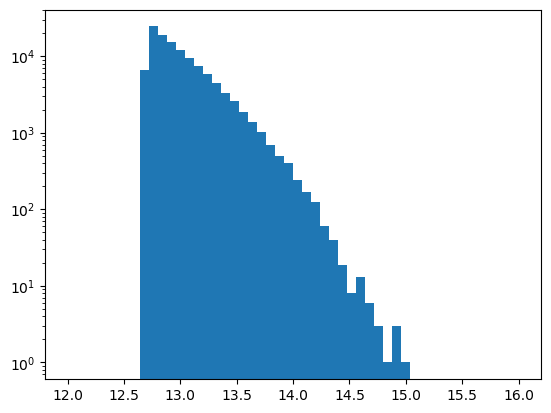

In [5]:
plt.figure()
_ = plt.hist(Mhalos2.flatten(), bins=50, range=(12, 16))
# _ = plt.hist(N_halos2.flatten(), bins=50, range=(0, 5))
# _ = plt.hist(c_halos_diff2.flatten(), bins=50, alpha=0.5)
# _ = plt.hist(c_halos_sim2.flatten(), bins=50,alpha=0.5)
# _ = plt.hist(pos_halos2.flatten(), bins=50)
# _ = plt.hist(v_halos_diff2.flatten(), bins=50)
# _ = plt.hist(v_halos_true2.flatten(), bins=50, alpha=0.5)

plt.yscale('log')
